In [5]:
import pandas as pd
import numpy as np
db = pd.read_csv(r"C:\Users\ADMIN\Desktop\linear_regression\Salary_dataset.csv")

In [3]:
#look dataset
db.head(5)

NameError: name 'db' is not defined

In [4]:
#drop indexing column
db.drop(columns='Unnamed: 0', inplace = True)

In [5]:
#change colume name
db.rename(columns={'YearsExperience': 'Experience'}, inplace=True)
db.head()

,Experience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [6]:
#check is there any missing value in my dataset
db.isnull().sum()

Experience    0
Salary        0
dtype: int64

In [7]:
#dataset stuctural overview
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Experience  30 non-null     float64
 1   Salary      30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [8]:
#statistical overview about dataset
db.describe()

,Experience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


<Axes: xlabel='Experience', ylabel='Salary'>

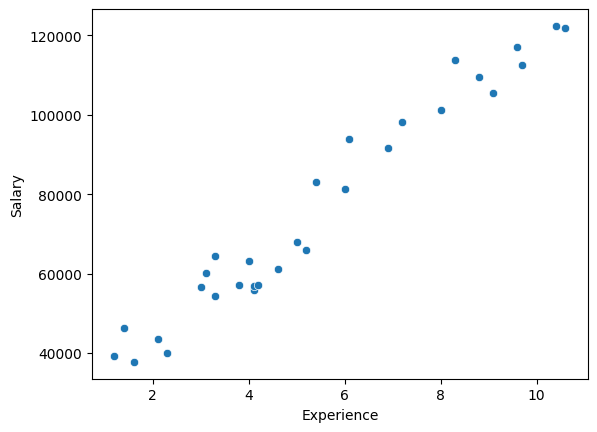

In [9]:
#visualize our dataset
import seaborn as sns
sns.scatterplot(x='Experience', y='Salary', data=db)

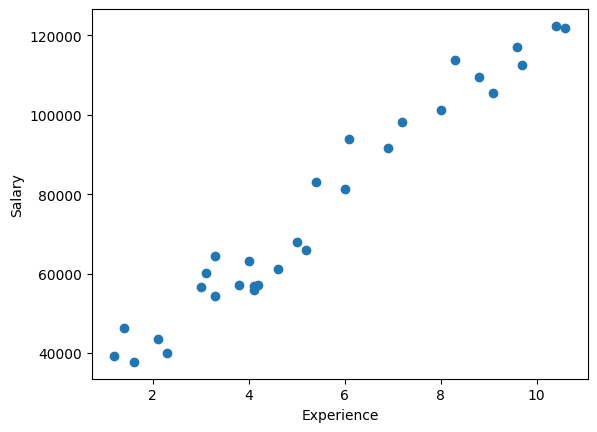

In [10]:
#ploat graph using Matploat lib
import matplotlib.pyplot as plt
plt.scatter(db['Experience'],db['Salary'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [11]:
#split input column
x = db.iloc[:,0].values.reshape(-1,1)

In [12]:
#split Output column
y = db.iloc[:,-1].values.reshape(-1,1)

In [13]:
#step 2 split input or output column using sklearn libaary
from sklearn.model_selection import train_test_split
#inside sklearn libaray there is model_selection module inside this module we use tarin_test_split
#method for spliting into input or output
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state =1)

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
#creating object of LinearRegression class
simple_lr = LinearRegression()
#train model
simple_lr.fit(x_train,y_train)

LinearRegression()

In [16]:
print('X test value:')
print(x_test)
print()
print('Y test value:')
print(y_test)

X test value:
[[5.4]
 [7.2]
 [4. ]
 [6.1]
 [4.6]
 [6.9]
 [9.6]
 [2.1]
 [8.8]]

Y test value:
[[ 83089.]
 [ 98274.]
 [ 63219.]
 [ 93941.]
 [ 61112.]
 [ 91739.]
 [116970.]
 [ 43526.]
 [109432.]]


In [17]:
#in line vale of m(slope) and b(intersept in y)
print('vale of m(slope):',simple_lr.coef_)
print('vale of b (intersept):',simple_lr.intercept_)

vale of m(slope): [[9202.23359825]]
vale of b (intersept): [25130.35435562]


In [18]:
simple_lr.predict([[7.2]])

array([[91386.43626305]])

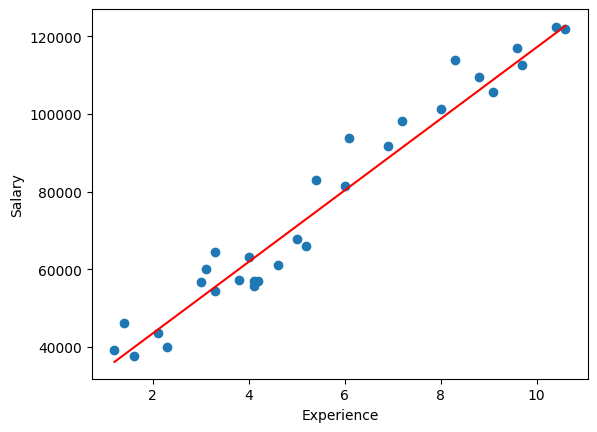

In [19]:
plt.scatter(x,y)
plt.plot(x,simple_lr.predict(x), color='red')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [20]:
#evalution
from sklearn.metrics import r2_score
r2_score(y_test,simple_lr.predict(x_test))

0.9248580247217076